# 02 - Wafer Map Story <a id="top"></a>

This notebook is a spatial supplement to `01_data_eda.ipynb`.

The first notebook introduced the synthetic manufacturing data, inspected the public tables, and summarized spatial behavior numerically. This notebook shows the same idea visually at wafer-map level.

The main question is:

> Where on the wafer do pass, fail, and not-tested dies appear?

The maps draw each die as a small square on a circular wafer footprint. Grey dies are not missing from the inline table. They simply do not have a downstream optical test row.

## Contents

- [Load generated data](#load-generated-data)
- [Build downstream status table](#build-status-table)
- [Plotting helpers](#plotting-helpers)
- [All wafers: pass, fail, and not tested](#all-wafers-status)
- [Select an example wafer for detailed inspection](#selected-wafer)
- [Resonance shift map for selected wafer](#resonance-map)
- [Radial cross-check](#radial-cross-check)
- [Summary](#summary)


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Patch, Rectangle
from matplotlib.colors import Normalize

from src.physics import MRRParameters
from src.utils import load_sources, validate_schemas


## Load generated data <a id="load-generated-data"></a>

This notebook uses the two public CSV files generated by the first notebook:

- `synthetic_inline_metrology.csv`
- `synthetic_downstream_wafer_test.csv`

The inline table contains every die. The downstream table contains only dies with usable downstream optical test results.

After loading the data, we compute a few geometry constants used only for drawing wafer maps: die pitch, die square size, and wafer radius.


In [ ]:
params = MRRParameters()

df_inline, df_downstream = load_sources(input_dir=str(DATA_DIR), prefix="synthetic")
validate_schemas(df_inline, df_downstream)

pitch_x = float(np.diff(np.sort(df_inline["x_mm"].unique())).min())
pitch_y = float(np.diff(np.sort(df_inline["y_mm"].unique())).min())
die_size = min(pitch_x, pitch_y) * 0.92
wafer_radius = float(df_inline["r_mm"].max()) + 0.5 * max(pitch_x, pitch_y)

print(f"Inline dies: {len(df_inline)}")
print(f"Downstream tested dies: {len(df_downstream)}")
print(f"Not tested dies: {len(df_inline) - len(df_downstream)}")
print(f"Die pitch: {pitch_x:.2f} mm x {pitch_y:.2f} mm")
print(f"Approximate wafer radius used for plotting: {wafer_radius:.2f} mm")


Loaded inline metrology: e:\Data_Science_Proj\data\synthetic_inline_metrology.csv
Loaded downstream wafer test: e:\Data_Science_Proj\data\synthetic_downstream_wafer_test.csv
Inline dies: 8000
Downstream tested dies: 3743
Not tested dies: 4257
Die pitch: 6.09 mm x 6.09 mm
Approximate wafer radius used for plotting: 72.04 mm


## Build downstream status table <a id="build-status-table"></a>

To draw wafer maps, we need one table with both die locations and downstream status.

We start from the inline table because it contains all dies. Then we left-join the downstream results. After the join, each die can be assigned one of three public downstream states:

- `Pass`: the die has a downstream row and `test_pass = 1`
- `Fail`: the die has a downstream row and `test_pass = 0`
- `Not tested`: the die has no downstream row

This distinction is important. A missing downstream row is not treated as a failure. It means the die was not tested downstream.


In [ ]:
df_status = df_inline.merge(
    df_downstream[
        [
            "wafer_id",
            "die_id",
            "lambda_res_nm",
            "q_loaded",
            "insertion_loss_db",
            "test_pass",
        ]
    ],
    on=["wafer_id", "die_id"],
    how="left",
)

status_order = ["Pass", "Fail", "Not tested"]

df_status["tested_downstream"] = df_status["test_pass"].notna()
df_status["downstream_status"] = np.select(
    [
        df_status["test_pass"].eq(1),
        df_status["test_pass"].eq(0),
        df_status["test_pass"].isna(),
    ],
    status_order,
    default="Unknown",
)

df_status["downstream_status"] = pd.Categorical(
    df_status["downstream_status"],
    categories=status_order,
    ordered=True,
)

df_status["lambda_shift_nm"] = df_status["lambda_res_nm"] - params.lambda0

status_counts = df_status["downstream_status"].value_counts().reindex(status_order)
display(status_counts.to_frame("die_count"))

display(df_status.head(5))


,die_count
downstream_status,
Pass,2261
Fail,1482
Not tested,4257


,wafer_id,lot_id,die_id,x_mm,y_mm,r_mm,wg_width_nm_meas,soi_thickness_nm_meas,etch_depth_nm_meas,roughness_rms_nm_meas,overlay_x_nm_meas,overlay_y_nm_meas,defect_density_cm2_meas,metrology_valid,lambda_res_nm,q_loaded,insertion_loss_db,test_pass,tested_downstream,downstream_status,lambda_shift_nm
0,W001,L01,D_R001_C008,-21.304348,-63.913043,67.370263,450.746043,220.765376,78.376078,1.833024,0.582978,1.501057,3496.593408,1,1551.742619,115942.398046,5.055187,0.0,True,Fail,1.742619
1,W001,L01,D_R001_C009,-15.217391,-63.913043,65.699666,450.520529,220.106638,77.595898,2.254063,0.717936,-3.135393,2782.650722,1,1550.478890,124349.837750,5.050780,0.0,True,Fail,0.478890
2,W001,L01,D_R001_C010,-9.130435,-63.913043,64.561923,450.819875,220.039471,81.925761,2.037319,-1.049406,-0.992895,1857.644245,1,NaN,NaN,NaN,NaN,False,Not tested,NaN
3,W001,L01,D_R001_C011,-3.043478,-63.913043,63.985466,450.597277,219.147633,86.167674,1.846491,-1.394339,-0.000943,3191.842153,1,1551.307346,120102.236522,5.052353,0.0,True,Fail,1.307346
4,W001,L01,D_R001_C012,3.043478,-63.913043,63.985466,451.583470,220.697219,82.182801,2.044996,2.122632,-1.286136,2427.490770,1,NaN,NaN,NaN,NaN,False,Not tested,NaN


## Plotting helpers <a id="plotting-helpers"></a>

The following helper functions are used only to draw wafer maps. They do not change the data.

Each die is drawn as a small square. The wafer outline is circular, so empty corners are expected: those grid locations are outside the usable wafer footprint.


In [ ]:
status_palette = {
    "Pass": "#2C7FB8",
    "Fail": "#D95F0E",
    "Not tested": "#D9D9D9",
}


def set_wafer_axes(ax):
    ax.add_patch(
        Circle(
            (0, 0),
            wafer_radius,
            fill=False,
            edgecolor="black",
            linewidth=1.0,
        )
    )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-wafer_radius - die_size, wafer_radius + die_size)
    ax.set_ylim(-wafer_radius - die_size, wafer_radius + die_size)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")


def rectangles_for(df):
    return [
        Rectangle(
            (row.x_mm - die_size / 2, row.y_mm - die_size / 2),
            die_size,
            die_size,
        )
        for row in df.itertuples(index=False)
    ]


def draw_status_map(ax, wafer_df):
    rects = rectangles_for(wafer_df)
    colors = [status_palette[str(status)] for status in wafer_df["downstream_status"]]
    collection = PatchCollection(
        rects,
        facecolor=colors,
        edgecolor="white",
        linewidth=0.2,
    )
    ax.add_collection(collection)
    set_wafer_axes(ax)


def draw_continuous_wafer_map(
    ax,
    wafer_df,
    value_col,
    value_min,
    value_max,
    cmap="turbo",
):
    not_tested = wafer_df[~wafer_df["tested_downstream"]]
    tested = wafer_df[wafer_df["tested_downstream"]]

    if len(not_tested):
        grey = PatchCollection(
            rectangles_for(not_tested),
            facecolor=status_palette["Not tested"],
            edgecolor="white",
            linewidth=0.2,
        )
        ax.add_collection(grey)

    collection = None
    if len(tested):
        collection = PatchCollection(
            rectangles_for(tested),
            cmap=cmap,
            norm=Normalize(vmin=value_min, vmax=value_max),
            edgecolor="white",
            linewidth=0.2,
        )
        collection.set_array(tested[value_col].to_numpy())
        ax.add_collection(collection)

    set_wafer_axes(ax)
    return collection


## All wafers: pass, fail, and not tested <a id="all-wafers-status"></a>

This is the main spatial EDA figure of the notebook.

Each subplot is one wafer. Each square is one die. Color encodes downstream status:

- blue: pass
- orange: fail
- grey: not tested

The goal is to inspect whether downstream outcomes appear spatially structured across wafers. If failures were purely random, the map would look like unstructured noise. Local clusters, edge-heavy patterns, or recurring missing-test regions suggest that the synthetic generator is producing spatial process variation.


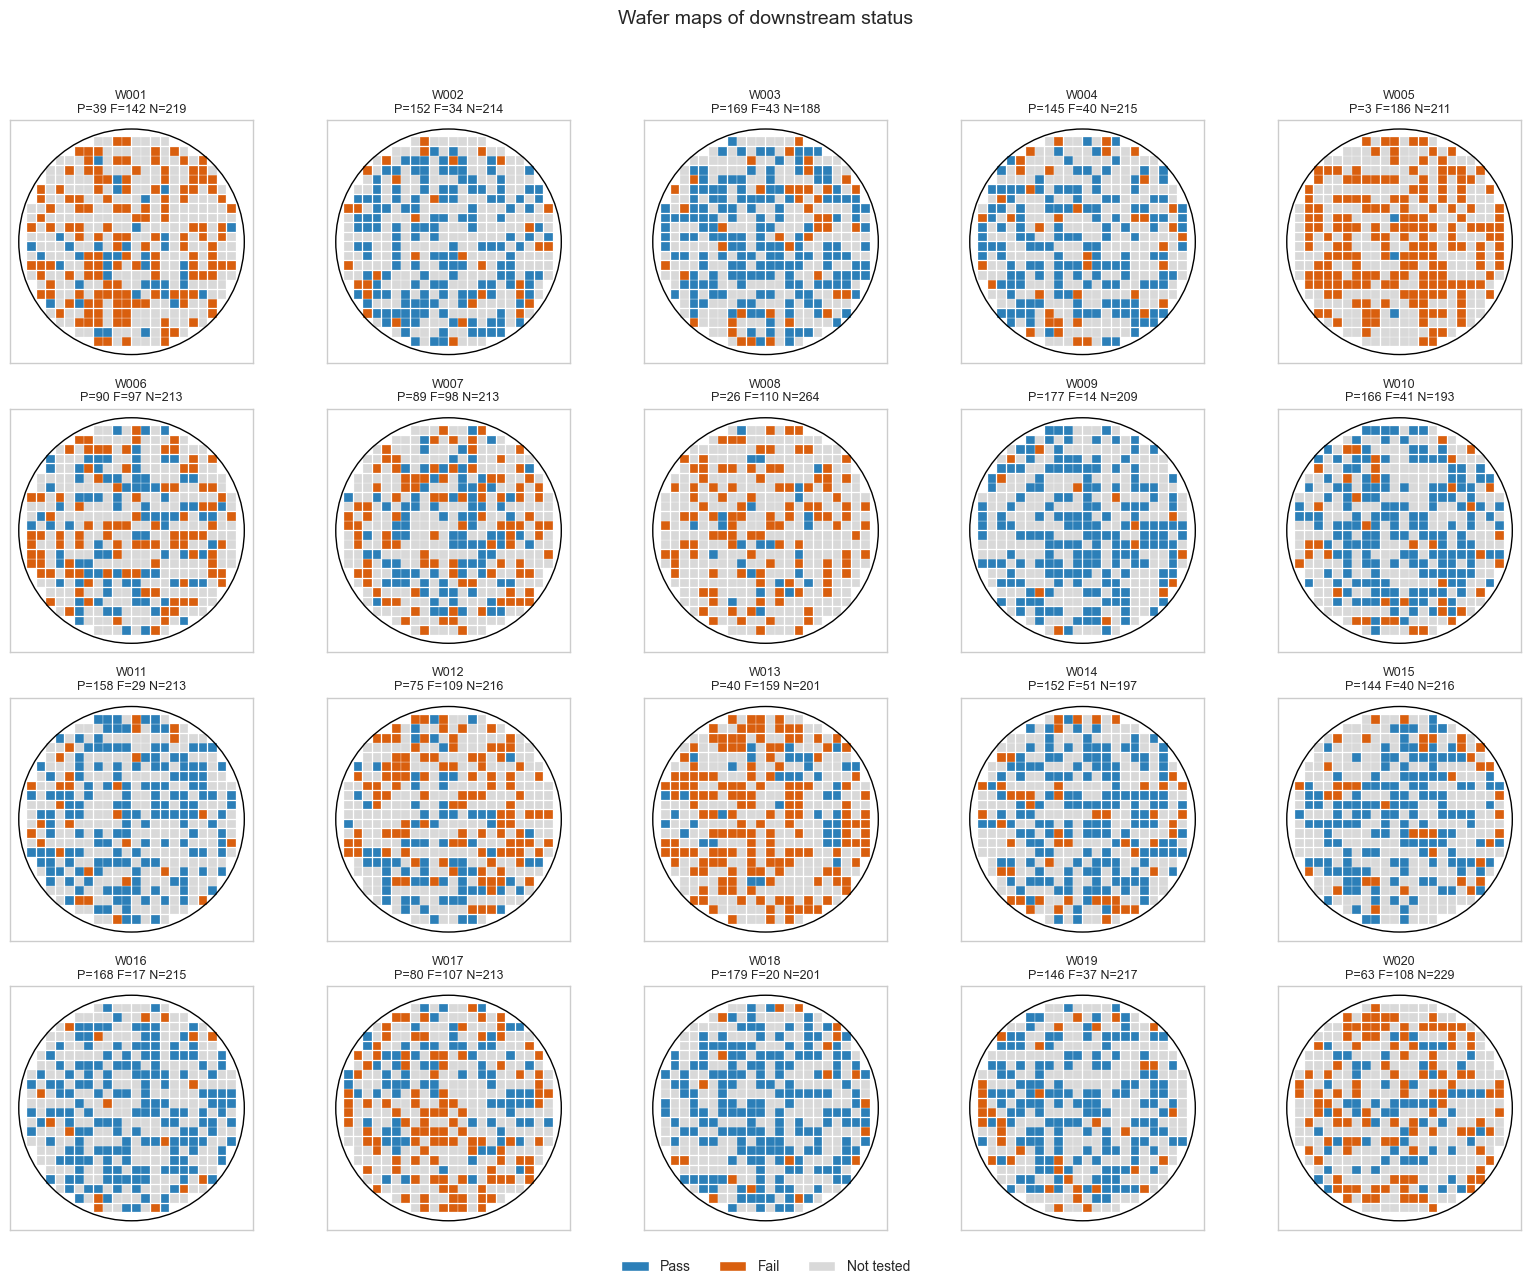

In [ ]:
wafer_ids = sorted(df_status["wafer_id"].unique())
n_cols = 5
n_rows = int(np.ceil(len(wafer_ids) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = np.asarray(axes).ravel()

for ax, wafer_id in zip(axes, wafer_ids):
    wafer_df = df_status[df_status["wafer_id"] == wafer_id]
    draw_status_map(ax, wafer_df)

    counts = wafer_df["downstream_status"].value_counts().reindex(status_order).fillna(0)
    ax.set_title(
        f"{wafer_id}\n"
        f"P={int(counts['Pass'])} "
        f"F={int(counts['Fail'])} "
        f"N={int(counts['Not tested'])}",
        fontsize=9,
    )

for ax in axes[len(wafer_ids):]:
    ax.set_visible(False)

legend_handles = [
    Patch(facecolor=status_palette[label], edgecolor="white", label=label)
    for label in status_order
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Wafer maps of downstream status", y=0.995, fontsize=14)
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()


## Select an example wafer for detailed inspection <a id="selected-wafer"></a>

The all-wafer map gives broad context. Next, we select one wafer for a closer look.

The selected wafer is not meant to represent the average wafer. It is selected as a high-failure example so that spatial structure is easier to inspect visually. The all-wafer map above provides the broader context and helps avoid treating this one wafer as the whole dataset.

The table below ranks wafers by number of failed downstream dies and by resonance-shift spread among tested dies.


In [ ]:
wafer_summary = (
    df_status.groupby("wafer_id")
    .agg(
        die_count=("die_id", "size"),
        tested_count=("tested_downstream", "sum"),
        pass_count=("test_pass", lambda s: int((s == 1).sum())),
        fail_count=("test_pass", lambda s: int((s == 0).sum())),
        not_tested_count=("tested_downstream", lambda s: int((~s).sum())),
        lambda_shift_std=("lambda_shift_nm", "std"),
    )
    .fillna({"lambda_shift_std": 0.0})
)

wafer_summary["coverage_rate"] = (
    wafer_summary["tested_count"] / wafer_summary["die_count"]
)
wafer_summary["fail_rate_among_tested"] = (
    wafer_summary["fail_count"] / wafer_summary["tested_count"]
)

selected_wafer = wafer_summary.sort_values(
    ["fail_count", "lambda_shift_std"],
    ascending=False,
).index[0]

print(f"Selected example wafer: {selected_wafer}")

display(
    wafer_summary.sort_values(
        ["fail_count", "lambda_shift_std"],
        ascending=False,
    ).head(8)
)


Selected example wafer: W005


,die_count,tested_count,pass_count,fail_count,not_tested_count,lambda_shift_std,coverage_rate,fail_rate_among_tested
wafer_id,,,,,,,,
W005,400,189,3,186,211,0.607966,0.4725,0.984127
W013,400,199,40,159,201,0.653663,0.4975,0.798995
W001,400,181,39,142,219,0.647806,0.4525,0.784530
W008,400,136,26,110,264,0.696908,0.3400,0.808824
W012,400,184,75,109,216,0.647416,0.4600,0.592391
W020,400,171,63,108,229,0.651577,0.4275,0.631579
W017,400,187,80,107,213,0.660932,0.4675,0.572193
W007,400,187,89,98,213,0.756997,0.4675,0.524064


## Continuous downstream maps for one selected wafer <a id="continuous-downstream-maps"></a>

The previous wafer maps showed categorical downstream status: `Pass`, `Fail`, and `Not tested`.

Here we inspect one selected wafer using continuous downstream measurements instead of categories.

We plot two measured optical quantities in physical wafer coordinates:

- `lambda_res_nm`: measured resonance wavelength
- `q_loaded`: measured loaded quality factor

Each square represents one die at its `(x_mm, y_mm)` location on the wafer.

Grey squares represent dies that were not tested downstream. Colored squares represent tested dies.

This view is complementary to the pass/fail maps. It does not try to prove an edge effect from a single wafer. Instead, it helps inspect whether the underlying downstream measurements show spatial structure before they are reduced to a pass/fail label.

Selected wafer: W005


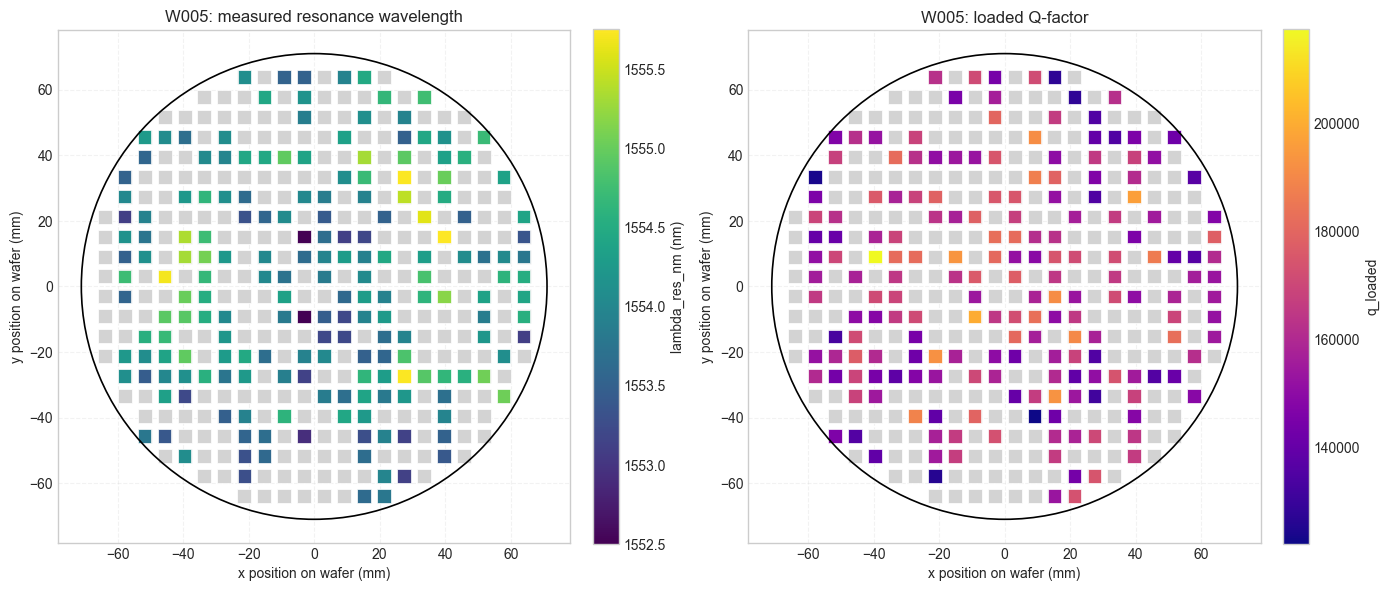

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd

# Build a merged spatial table with all inline dies and downstream values where available.
df_spatial = df_inline.merge(
    df_downstream[
        [
            "wafer_id",
            "die_id",
            "lambda_res_nm",
            "q_loaded",
            "test_pass",
        ]
    ],
    on=["wafer_id", "die_id"],
    how="left",
)

df_spatial["tested_downstream"] = df_spatial["lambda_res_nm"].notna()

# If selected_wafer already exists earlier in the notebook, this reuses it.
# Otherwise, select a high-failure wafer as an illustrative example.
if "selected_wafer" not in globals():
    wafer_summary = (
        df_spatial.groupby("wafer_id")
        .agg(
            tested_count=("tested_downstream", "sum"),
            fail_count=("test_pass", lambda s: s.eq(0).sum()),
            lambda_std=("lambda_res_nm", "std"),
        )
        .fillna(0)
    )

    selected_wafer = (
        wafer_summary
        .sort_values(["fail_count", "lambda_std"], ascending=False)
        .index[0]
    )

print(f"Selected wafer: {selected_wafer}")

wafer_df = df_spatial[df_spatial["wafer_id"] == selected_wafer].copy()
tested_df = wafer_df[wafer_df["tested_downstream"]].copy()

wafer_radius = wafer_df["r_mm"].max() * 1.03


def plot_continuous_wafer_map(
    ax,
    wafer_df,
    tested_df,
    value_col,
    title,
    colorbar_label,
    cmap="viridis",
):
    """Plot one continuous downstream value as a wafer map."""

    # Background: all dies, including not-tested dies
    ax.scatter(
        wafer_df["x_mm"],
        wafer_df["y_mm"],
        marker="s",
        s=95,
        color="lightgrey",
        edgecolor="white",
        linewidth=0.5,
        label="Not tested",
    )

    # Foreground: tested dies colored by downstream value
    scatter = ax.scatter(
        tested_df["x_mm"],
        tested_df["y_mm"],
        c=tested_df[value_col],
        marker="s",
        s=95,
        cmap=cmap,
        edgecolor="white",
        linewidth=0.5,
    )

    wafer_outline = Circle(
        (0, 0),
        wafer_radius,
        fill=False,
        color="black",
        linewidth=1.2,
    )
    ax.add_patch(wafer_outline)

    ax.set_title(title)
    ax.set_xlabel("x position on wafer (mm)")
    ax.set_ylabel("y position on wafer (mm)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", alpha=0.25)

    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(colorbar_label)

    return scatter


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_continuous_wafer_map(
    ax=axes[0],
    wafer_df=wafer_df,
    tested_df=tested_df,
    value_col="lambda_res_nm",
    title=f"{selected_wafer}: measured resonance wavelength",
    colorbar_label="lambda_res_nm (nm)",
    cmap="viridis",
)

plot_continuous_wafer_map(
    ax=axes[1],
    wafer_df=wafer_df,
    tested_df=tested_df,
    value_col="q_loaded",
    title=f"{selected_wafer}: loaded Q-factor",
    colorbar_label="q_loaded",
    cmap="plasma",
)

plt.tight_layout()
plt.show()

The left map shows the measured resonance wavelength for tested dies.

The right map shows the measured loaded Q-factor for the same wafer.

These maps should be interpreted carefully. A single wafer is not enough to prove a general spatial effect. The goal is to inspect whether continuous downstream measurements appear spatially structured and how they relate to the categorical pass/fail maps.

If `q_loaded` shows clearer spatial degradation than `lambda_res_nm`, that is expected: the generator's edge-related degradation is more directly connected to quality loss and downstream failure than to resonance wavelength alone.

## Summary <a id="summary"></a>

This notebook visualized the downstream status of dies at wafer-map level.

The main takeaways are:

- pass, fail, and not-tested states can be inspected spatially
- not-tested dies are visible as a separate category, not treated as failures
- some wafers show clustered or edge-related failure behavior
- continuous resonance-shift maps help connect categorical status outcomes back to optical measurements
- the radial cross-check connects the wafer maps to the center-to-edge behavior summarized in the first notebook

This notebook does not prove that the synthetic model represents a real fab. It supports a narrower claim: the generated dataset is spatially inspectable and contains structured wafer-level variation.

The next notebook moves from spatial EDA to a simple predictive baseline.
